# Amazon Delivery Dataset – Exploratory Data Analysis

This notebook explores the Amazon Delivery Dataset to understand factors influencing delivery efficiency.  
We focus on **Agent Rating** and **Delivery Duration** to test the hypothesis:  
*Higher-rated agents deliver faster than lower-rated agents.*

## Dataset Overview

- **Rows:** 43,739 delivery records  
- **Columns:** 16 of them including:
  - `Order_ID`: Unique identifier for each order
  - `Agent_Age`: Age of the delivery agent
  - `Agent_Rating`: Performance score (1–5 scale)
  - `Store_Latitude` / `Store_Longitude`: Store coordinates
  - `Drop_Latitude` / `Drop_Longitude`: Delivery coordinates
  - `Order_Date`, `Order_Time`, `Pickup_Time`: Timestamps
  - Derived feature: **Delivery_Duration** = Drop_Time – Pickup_Time

**Business Context:**  
Understanding how agent ratings relate to delivery speed can guide training, incentives, and staffing.

In [1]:
import pandas as pd

# Load dataset
amazon_df = pd.read_csv("../amazon_delivery.csv")

# Inspect shape and first rows
print("Shape:", amazon_df.shape)
amazon_df.head()

Shape: (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [2]:
# Summary statistics
amazon_df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [3]:
amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [4]:
amazon_df.isna().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [5]:
# Make all column names lowercase
amazon_df.columns = amazon_df.columns.str.lower()

# Verify the change
print(amazon_df.columns)

Index(['order_id', 'agent_age', 'agent_rating', 'store_latitude',
       'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date',
       'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area',
       'delivery_time', 'category'],
      dtype='object')


In [6]:
# Count NaNs in Agent_Rating
agent_rating_isna_count = amazon_df['agent_rating'].isna().sum()

# Total rows
number_of_rows = len(amazon_df)

# Percentage of NaNs
percentage_missing = (agent_rating_isna_count / number_of_rows) * 100

print(f"Percentage of missing Agent_Rating values: {percentage_missing:.2f}%")

Percentage of missing Agent_Rating values: 0.12%


0.12% of records have a missing Agent_Rating so we will set the missing values to the mode of column
There were choices: 
- delete the rows
- set to mode, median or mean

I have chossen mode.

In [7]:
mode_value = amazon_df['agent_rating'].mode()[0]
amazon_df['agent_rating'] = amazon_df['agent_rating'].fillna(mode_value)

91 of the 43739 rows in the `Weather` column are nulls. We could pick one of the existing values based on location and date time but this is overkill. We will replace them with 'Unknown'.

In [8]:
amazon_df["weather"] = amazon_df["weather"].fillna("Unknown")

While plotting Delivery Time against Traffic I discovered that there are 91 rows where the `Traffic` column values == 'NaN ' (a string rather than NaN). Again, we will replace them with 'Unknown'.

In [9]:
amazon_df['traffic'] = amazon_df['traffic'].replace('NaN', 'Unknown')

Finally, we shall remove leading and trailing spaces.

In [10]:
# Some category values have trailing spaces
# Remove leading and trailing spaces from category columns
amazon_df['weather'] = amazon_df['weather'].str.strip()
amazon_df['traffic'] = amazon_df['traffic'].str.strip()
amazon_df['vehicle'] = amazon_df['vehicle'].str.strip()
amazon_df['area'] = amazon_df['area'].str.strip()
amazon_df['category'] = amazon_df['category'].str.strip()

## Change column data types

The columns below are more accurately reflected as a data type of `category`:
  - `weather`
  - `traffic`
  - `vehicle`
  - `area`
  - `category`

In [11]:
# List of columns to convert
cols_to_convert = ['weather', 'traffic', 'vehicle', 'area', 'category']

# Convert each column to string type
amazon_df[cols_to_convert] = amazon_df[cols_to_convert].astype('category')

# Verify the change
amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   order_id         43739 non-null  object  
 1   agent_age        43739 non-null  int64   
 2   agent_rating     43739 non-null  float64 
 3   store_latitude   43739 non-null  float64 
 4   store_longitude  43739 non-null  float64 
 5   drop_latitude    43739 non-null  float64 
 6   drop_longitude   43739 non-null  float64 
 7   order_date       43739 non-null  object  
 8   order_time       43739 non-null  object  
 9   pickup_time      43739 non-null  object  
 10  weather          43739 non-null  category
 11  traffic          43739 non-null  category
 12  vehicle          43739 non-null  category
 13  area             43739 non-null  category
 14  delivery_time    43739 non-null  int64   
 15  category         43739 non-null  category
dtypes: category(5), float64(5), int64(2), ob

In [12]:
amazon_df.head()

,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,weather,traffic,vehicle,area,delivery_time,category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


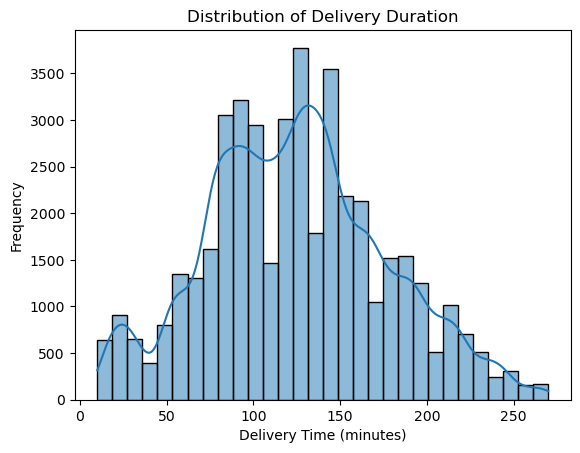

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram of delivery time
sns.histplot(amazon_df['delivery_time'], bins=30, kde=True)
plt.title("Distribution of Delivery Duration")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.show()

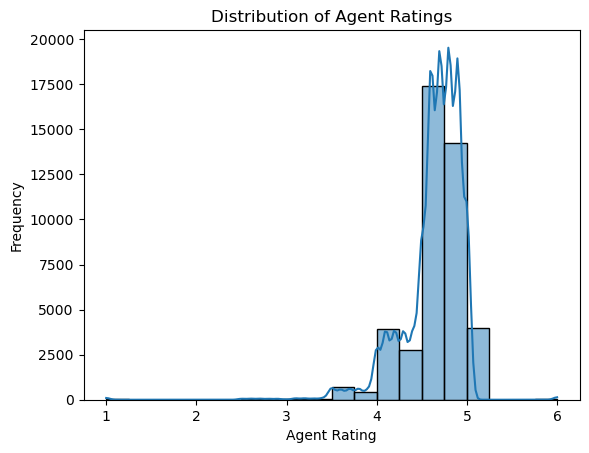

In [14]:
# Histogram of agent ratings
sns.histplot(amazon_df['agent_rating'], bins=20, kde=True)
plt.title("Distribution of Agent Ratings")
plt.xlabel("Agent Rating")
plt.ylabel("Frequency")
plt.show()

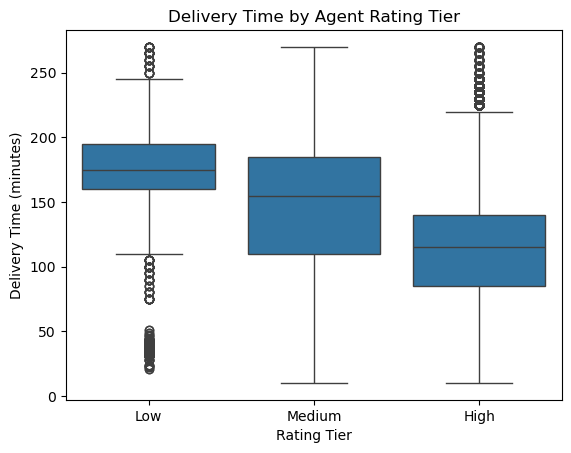

In [15]:
# Boxplot of delivery time by rating tier
amazon_df['rating_tier'] = pd.cut(amazon_df['agent_rating'], bins=[3.0,4.0,4.5,5.0], labels=['Low','Medium','High'])

sns.boxplot(x='rating_tier', y='delivery_time', data=amazon_df)
plt.title("Delivery Time by Agent Rating Tier")
plt.xlabel("Rating Tier")
plt.ylabel("Delivery Time (minutes)")
plt.show()

In [16]:
# Check counts for each categorical variable
print(amazon_df['weather'].value_counts())
print(amazon_df['traffic'].value_counts())
print(amazon_df['vehicle'].value_counts())
print(amazon_df['area'].value_counts())
print(amazon_df['category'].value_counts())

weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
Unknown         91
Name: count, dtype: int64
traffic
Low       14999
Jam       13725
Medium    10628
High       4296
NaN          91
Name: count, dtype: int64
vehicle
motorcycle    25527
scooter       14639
van            3558
bicycle          15
Name: count, dtype: int64
area
Metropolitian    32698
Urban             9751
Other             1138
Semi-Urban         152
Name: count, dtype: int64
category
Electronics     2849
Books           2824
Jewelry         2802
Toys            2781
Skincare        2772
Snacks          2770
Outdoors        2747
Apparel         2726
Sports          2719
Grocery         2691
Pet Supplies    2690
Home            2685
Cosmetics       2677
Kitchen         2673
Clothing        2667
Shoes           2666
Name: count, dtype: int64


## EDA Examples Using Categorical Columns
1. Delivery Time by Weather

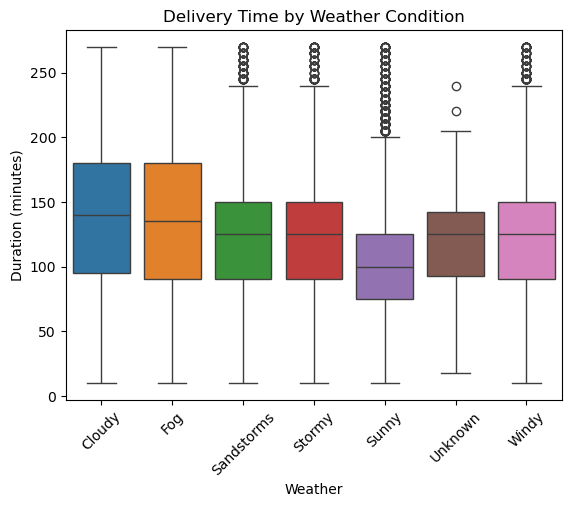

In [17]:
sns.boxplot(x='weather', y='delivery_time', data=amazon_df, hue='weather')
plt.title("Delivery Time by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Duration (minutes)")
plt.xticks(rotation=45)
plt.show()

2. Delivery Time by Traffic

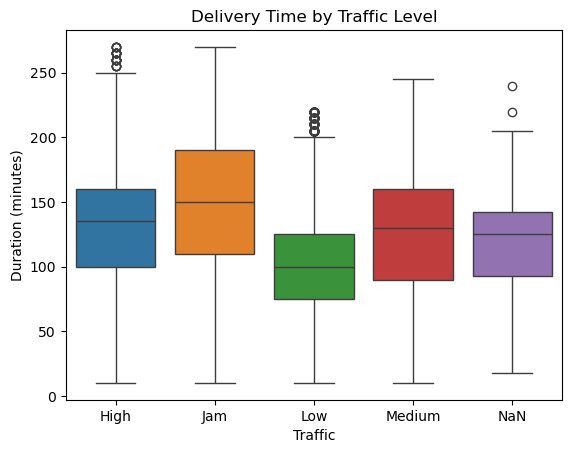

In [18]:
sns.boxplot(x='traffic', y='delivery_time', data=amazon_df, hue='traffic')
plt.title("Delivery Time by Traffic Level")
plt.xlabel("Traffic")
plt.ylabel("Duration (minutes)")
plt.show()

3. Delivery Time by Vehicle Type

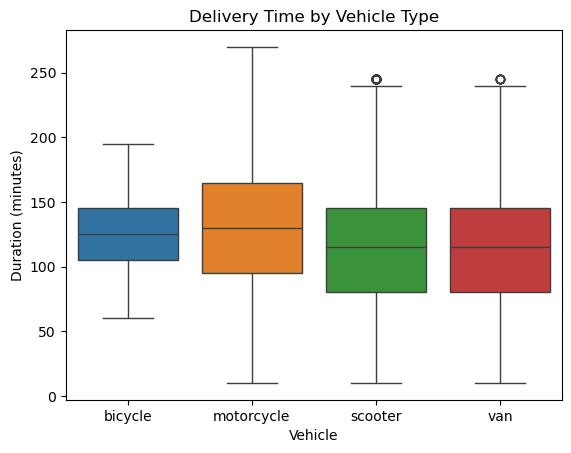

In [19]:
sns.boxplot(x='vehicle', y='delivery_time', data=amazon_df, hue='vehicle')
plt.title("Delivery Time by Vehicle Type")
plt.xlabel("Vehicle")
plt.ylabel("Duration (minutes)")
plt.show()

4. Delivery Time by Area

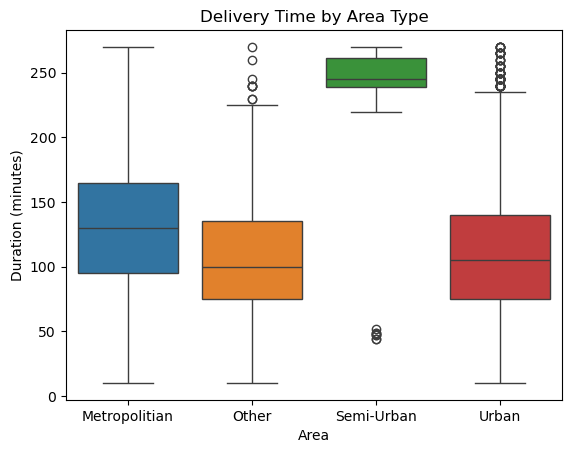

In [20]:
sns.boxplot(x='area', y='delivery_time', data=amazon_df, hue='area')
plt.title("Delivery Time by Area Type")
plt.xlabel("Area")
plt.ylabel("Duration (minutes)")
plt.show()

5. Delivery Time by Product Category

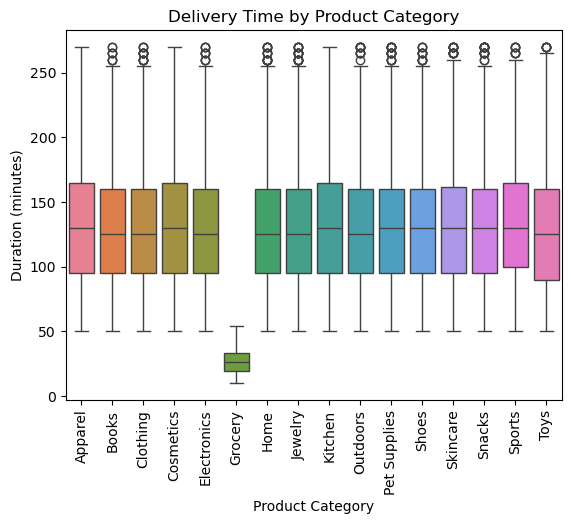

In [21]:
sns.boxplot(x='category', y='delivery_time', data=amazon_df, hue='category')
plt.title("Delivery Time by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Duration (minutes)")
plt.xticks(rotation=90)
plt.show()

### Exploratory Data Analysis (Categorical Variables)

We explored how categorical features influence delivery duration:

- **weather:** Stormy conditions lead to longer delivery times compared to Sunny days.
- **traffic:** High traffic and jams significantly increase delivery duration.
- **vehicle:** Vehicle type does not substantially effect delivery times.
- **area:** Semi-urban deliveries are significantly slower than urban/metropolitan deliveries.
- **category:** The Grocery category shows shorter average delivery times.

### What country is the data set taken from?

In [22]:
import folium
from folium.plugins import HeatMap

# 1) Filter invalid store coordinates
valid_stores = amazon_df[(amazon_df['store_latitude'] != 0) & (amazon_df['store_longitude'] != 0)]

# 2) Group by store and count drops
store_counts = (
    valid_stores.groupby(['store_latitude', 'store_longitude'])
         .size()
         .reset_index(name='drop_count')
)

store_counts = store_counts.sort_values('drop_count', ascending=False)

# 3) Build heat data as [lat, lon, weight]
heat_data = store_counts[['store_latitude', 'store_longitude', 'drop_count']].values.tolist()

# 4) Create the map centered on the mean of selected stores
amazon_map = folium.Map(
    location=['23.185884', '79.974380'],
    zoom_start=5,
    tiles="cartodbpositron"  # lighter basemap for clarity
)

# 5) Add heat layer
HeatMap(
    heat_data,
    radius=25,        # spread of each point
    blur=15,          # smoothing
    max_zoom=12,      # when to start dissipating
    min_opacity=0.4,  # floor opacity
).add_to(amazon_map)

# 6) Add labeled markers to show counts
for _, r in store_counts.iterrows():
    folium.CircleMarker(
        location=[r['store_latitude'], r['store_longitude']],
        radius=6,
        color=None,
        fill=True,
        fill_opacity=0.0,  # invisible circle, popup only
        popup=f"Drops: {r['drop_count']}"
    ).add_to(amazon_map)

display(amazon_map)

In [23]:
from scipy.stats import ttest_ind

### Hypothesis 1
Delivery times differ significantly between Low and High traffic

In [24]:
print("Hypothesis: delivery times differ significantly between Low and High traffic.")
# Extract delivery times for Low vs High traffic
low_traffic = amazon_df[amazon_df['traffic'] == 'Low']['delivery_time']
high_traffic = amazon_df[amazon_df['traffic'] == 'High']['delivery_time']

# Run independent samples t-test
t_statistic, p_value = ttest_ind(low_traffic, high_traffic, equal_var=False)

print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("Reject H0: Delivery times differ significantly between Low and High traffic.")
else:
    print("Fail to reject H0: No significant difference in delivery times between Low and High traffic.")


Hypothesis: delivery times differ significantly between Low and High traffic.
t-statistic: -35.009450838810125
p-value: 2.0607528193610863e-244
Reject H0: Delivery times differ significantly between Low and High traffic.


### Hypothesis 2
Delivery times differ significantly between Low and Jam traffic

In [25]:
print("Hypothesis: delivery times differ significantly between Low and Jam traffic.")
# Extract delivery times for Low vs High traffic
low_traffic = amazon_df[amazon_df['traffic'] == 'Low']['delivery_time']
jam_traffic = amazon_df[amazon_df['traffic'] == 'Jam']['delivery_time']

# Run independent samples t-test
t_statistic, p_value = ttest_ind(low_traffic, jam_traffic, equal_var=False)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject H0: Delivery times differ significantly between Low and Jam traffic.")
else:
    print("Fail to reject H0: No significant difference in delivery times between Low and Jam traffic.")


Hypothesis: delivery times differ significantly between Low and Jam traffic.
t-statistic: -80.10764119150915
p-value: 0.0
Reject H0: Delivery times differ significantly between Low and Jam traffic.


I expected the delivery times to differ significantly between Low and Jam traffic. This was not the case, so I tried a different tack. We know the time it takes to deliver a package and can work out the distance, in kilometres, between to sets of coordinates using the Haversine formula. From there we can calculate the average speed of the vehicle from store to drop point.

### 🧮 Haversine Formula
The formula for distance between two latitude/longitude points is:

![Alt text](HaversineFormula.png)

- 𝑅 = Earth’s radius (~6371 km)
- 𝜑1, 𝜑2 = latitudes in radians
- 𝜆1, 𝜆2 = longitudes in radians

In [26]:
import numpy as np

# Earth radius in kilometers
R = 6371  

# Convert degrees to radians
store_lat = np.radians(amazon_df['store_latitude'])
store_lon = np.radians(amazon_df['store_longitude'])
drop_lat = np.radians(amazon_df['drop_latitude'])
drop_lon = np.radians(amazon_df['drop_longitude'])

# Differences
dlat = drop_lat - store_lat
dlon = drop_lon - store_lon

# Haversine formula
a = np.sin(dlat/2)**2 + np.cos(store_lat) * np.cos(drop_lat) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

# Distance in km
amazon_df['distance_km'] = R * c

# Speed in in km per minute
amazon_df['speed_km_per_minute'] = amazon_df['distance_km'] / amazon_df['delivery_time']

# Check result
print(amazon_df[['store_latitude','store_longitude','drop_latitude','drop_longitude','distance_km', 'delivery_time', 'speed_km_per_minute']].head())


   store_latitude  store_longitude  drop_latitude  drop_longitude  \
0       22.745049        75.892471      22.765049       75.912471   
1       12.913041        77.683237      13.043041       77.813237   
2       12.914264        77.678400      12.924264       77.688400   
3       11.003669        76.976494      11.053669       77.026494   
4       12.972793        80.249982      13.012793       80.289982   

   distance_km  delivery_time  speed_km_per_minute  
0     3.025149            120             0.025210  
1    20.183530            165             0.122324  
2     1.552758            130             0.011944  
3     7.790401            105             0.074194  
4     6.210138            150             0.041401  


In [27]:
# Drop missing values for for cleaner data
df = amazon_df[['speed_km_per_minute', 'agent_rating']].dropna()

# Create high-speed and low-speed groups using the median
median_speed = df['speed_km_per_minute'].median()

low_speed_ratings = df[df['speed_km_per_minute'] <= median_speed]['agent_rating']
high_speed_ratings = df[df['speed_km_per_minute'] > median_speed]['agent_rating']

# Run independent samples t-test
t_stat, p_value = ttest_ind(high_speed_ratings, low_speed_ratings, equal_var=False)

print("Median speed:", median_speed)
print("High-speed mean rating:", high_speed_ratings.mean())
print("Low-speed mean rating:", low_speed_ratings.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject H0: Agent ratings differ significantly between high- and low-speed vehicles.")
else:
    print("Fail to reject H0: No significant difference in agent ratings based on speed.")


Median speed: 0.07245420610446417
High-speed mean rating: 4.6527367506516075
Low-speed mean rating: 4.615235482395977
t-statistic: 11.739605816171297
p-value: 8.914064631222425e-32
Reject H0: Agent ratings differ significantly between high- and low-speed vehicles.


In [28]:
# Group by vehicle type and compute mean speed
vehicle_speed = (
    amazon_df.groupby('vehicle', observed=True)['speed_km_per_minute']
    .mean()
    .sort_values(ascending=False)
)

print(vehicle_speed)

# Fastest vehicle type
fastest_type = vehicle_speed.idxmax()
fastest_speed = vehicle_speed.max()

print("\nFastest vehicle type:", fastest_type)
print("Average speed (km/min):", fastest_speed)

vehicle
bicycle       33.831671
van            0.914315
scooter        0.379971
motorcycle     0.300920
Name: speed_km_per_minute, dtype: float64

Fastest vehicle type: bicycle
Average speed (km/min): 33.83167131820073


In [32]:
scooter_speed = amazon_df[amazon_df['vehicle'] == 'scooter']['speed_km_per_minute']
other_speed = amazon_df[amazon_df['vehicle'] != 'scooter']['speed_km_per_minute']

t_stat, p_value = ttest_ind(scooter_speed, other_speed, equal_var=False)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("Reject H0: Scooters travel at significantly higher speeds.")
else:
    print("Fail to reject H0: No significant difference in travel speeds.")


t-statistic: -0.22917269039525381
p-value: 0.8187362125908857
Fail to reject H0: No significant difference in travel speeds.
